<a href="https://colab.research.google.com/github/Hadeel-93/HW-3/blob/main/HW_3Q_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import diabetes.csv from the Drive
file_path = '/content/drive/My Drive/Introduction to Machine Learning/diabetes.csv'
dataset = pd.DataFrame(pd.read_csv(file_path))
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = dataset.iloc[:, [0,1,2,3,4,5,6,7]].values
Y = dataset.iloc[:, 8].values

In [4]:
X[0:10]

array([[6.000e+00, 1.480e+02, 7.200e+01, 3.500e+01, 0.000e+00, 3.360e+01,
        6.270e-01, 5.000e+01],
       [1.000e+00, 8.500e+01, 6.600e+01, 2.900e+01, 0.000e+00, 2.660e+01,
        3.510e-01, 3.100e+01],
       [8.000e+00, 1.830e+02, 6.400e+01, 0.000e+00, 0.000e+00, 2.330e+01,
        6.720e-01, 3.200e+01],
       [1.000e+00, 8.900e+01, 6.600e+01, 2.300e+01, 9.400e+01, 2.810e+01,
        1.670e-01, 2.100e+01],
       [0.000e+00, 1.370e+02, 4.000e+01, 3.500e+01, 1.680e+02, 4.310e+01,
        2.288e+00, 3.300e+01],
       [5.000e+00, 1.160e+02, 7.400e+01, 0.000e+00, 0.000e+00, 2.560e+01,
        2.010e-01, 3.000e+01],
       [3.000e+00, 7.800e+01, 5.000e+01, 3.200e+01, 8.800e+01, 3.100e+01,
        2.480e-01, 2.600e+01],
       [1.000e+01, 1.150e+02, 0.000e+00, 0.000e+00, 0.000e+00, 3.530e+01,
        1.340e-01, 2.900e+01],
       [2.000e+00, 1.970e+02, 7.000e+01, 4.500e+01, 5.430e+02, 3.050e+01,
        1.580e-01, 5.300e+01],
       [8.000e+00, 1.250e+02, 9.600e+01, 0.000e+00, 0.0

In [5]:
#split our Data set into Training Data(0.8) and Test Data(0.2). Training data will be used to train our
#Logistic model and Test data will be used to validate our model.
#Sklearn is used to split our data. We’ll import  train_test_split from sklearn.model_selection

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0, stratify =Y)

In [6]:
#Now feature scaling to scale our data between 0 and 1 to get better accuracy.
#Here Scaling is important because there is a huge difference between Age and EstimatedSalay.

from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [7]:
#Import LogisticRegression from sklearn.linear_model
#Make an instance classifier of the object LogisticRegression and give random_state =  0
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(solver= 'liblinear', penalty="l2", C=1.0, random_state=0, max_iter=1000)
classifier.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, random_state=0, solver='liblinear')

In [8]:
Y_pred = classifier.predict(X_test)

In [9]:
#Using Confusion matrix we can get accuracy of our model.

from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(Y_test, Y_pred)
cnf_matrix

array([[89, 11],
       [23, 31]])

In [10]:
#Evaluate the model using model evaluation metrics such as accuracy, precision, recall, and F1 score.
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))
print("Precision:",metrics.precision_score(Y_test, Y_pred))
print("Recall:",metrics.recall_score(Y_test, Y_pred))
print("F1 Score:",metrics.f1_score(Y_test, Y_pred))

Accuracy: 0.7792207792207793
Precision: 0.7380952380952381
Recall: 0.5740740740740741
F1 Score: 0.6458333333333334


Text(0.5, 427.9555555555555, 'Predicted label')

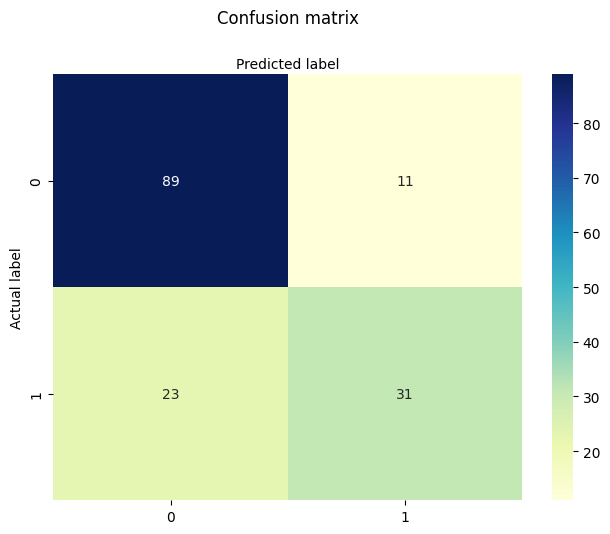

In [11]:
#Visualize the results of the model in the form of a confusion matrix using matplotlib and seaborn.
#Here, visualize the confusion matrix using Heatmap.
import seaborn as sns
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

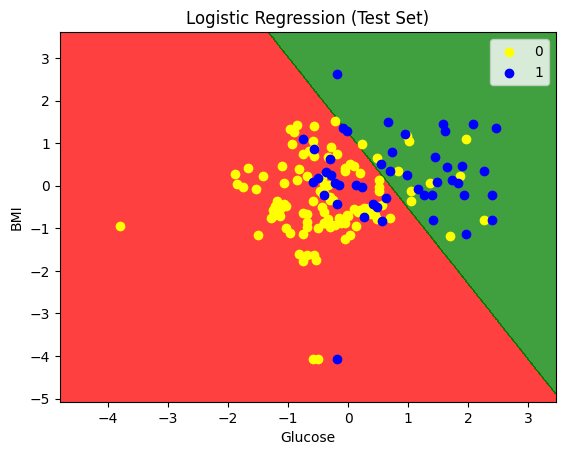

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load the diabetes dataset
file_path = '/content/drive/My Drive/Introduction to Machine Learning/diabetes.csv'
data = pd.read_csv(file_path)

# Use ONLY Glucose and BMI
X = data[['Glucose', 'BMI']].values
y = data['Outcome'].values

# 80% training, 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0
)

# Standardize the features
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Train Logistic Regression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, Y_train)

# -----------------------------------
# Plot Logistic Regression boundary
# -----------------------------------

X_set, Y_set = X_test, Y_test

X1, X2 = np.meshgrid(
    np.arange(
        start=X_set[:, 0].min() - 1,
        stop=X_set[:, 0].max() + 1,
        step=0.01
    ),
    np.arange(
        start=X_set[:, 1].min() - 1,
        stop=X_set[:, 1].max() + 1,
        step=0.01
    )
)

plt.contourf(
    X1,
    X2,
    classifier.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(Y_set)):
    plt.scatter(
        X_set[Y_set == j, 0],
        X_set[Y_set == j, 1],
        c=ListedColormap(('yellow', 'blue'))(i),
        label=j
    )

plt.title('Logistic Regression (Test Set)')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend()
plt.show()